In [56]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # load FITS module


### Remember that we have a few categories of errors:

- Illegitimate error (you did an oopsie in your method/assumptions)


- Systematic error (predictable difference between data and measurement)
     
                
- Random error (differences can only be described probabilistically)


### In astronomy, or any other science, we need data that we trust are good to fit our models to; need a good signal and low errors, or in other words a good signal-to-noise ratio:


  $$ \mathrm{SNR} = \frac{\rm value}{\rm uncertainty}$$

    - note that the uncertainty, or noise, here includes *all* sources of noise combined

    - You already know how to calculate uncertainties, numbers of photons, noise from photon statistics and (soon) from detectors
    - But, it can get complicated, even if it's "just" a lot of simple things contributing
    

### Why is SNR important? Let's see a few examples:

<img src="wispit_2b.png" width="200" height="300"/>


In [57]:
vals = np.loadtxt('2Ddatasnr.dat')

In [58]:
#vals.shape
d1, d2 = vals.shape

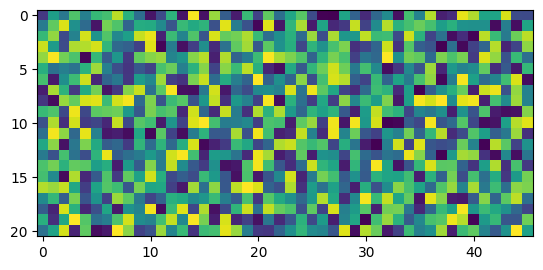

In [59]:
#SNR of <0.1
noise1 = 1000 * np.random.random((d1,d2))
dm = plt.imshow( vals+noise1 )

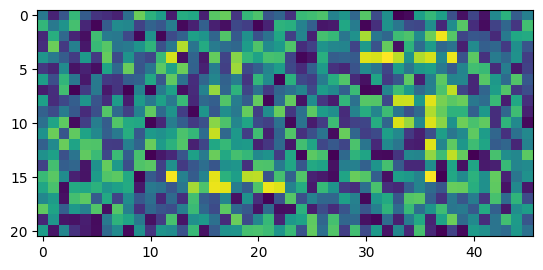

In [60]:
#SNR of ~1
noise2 = 10 * np.random.random((d1,d2))
dm = plt.imshow( vals+noise2 )

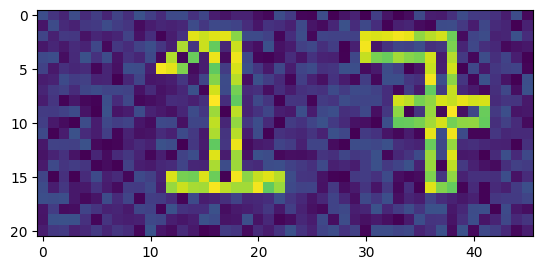

In [61]:
#SNR of ~10
noise3 = np.random.random((d1,d2))
dm = plt.imshow( vals+noise3 )

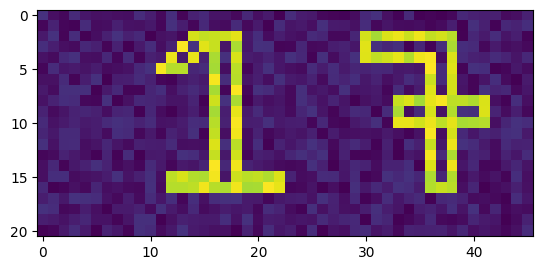

In [62]:
#SNR of ~40
noise4 = 0.5* np.random.random((d1,d2))
dm = plt.imshow( vals+noise4 )

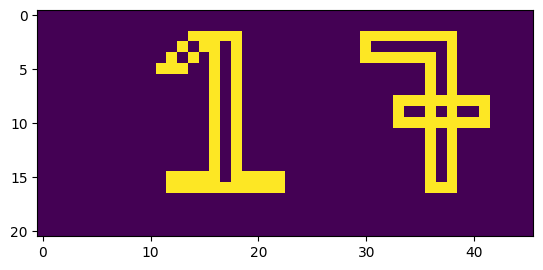

In [63]:
#SNR of 1000++
noise5 = 0.01 * np.random.random((d1,d2))
dm = plt.imshow( vals+noise5 )

### Rule-of-thumb: don't trust things with SNR < 3 (or ideally more...)

### Calculating the SNR:

- Number of photons from anything: $N_\textrm{photons} = \frac{ E }{ h\nu} = \frac{E\lambda}{hc}$

- To follow poisson statistics we need to have a nearly constant average number of photons arriving at our sensor per time interval t (generally, number fluctuates per unit time but average is the same), also photons arrive independently of one another. Both are good assumptions in astronomy. Then:
    - Intrinsic noise in any measurement based on photons (Poisson noise): $\sigma_{N} = \sqrt{N}$
    
    </br>
### The ultimate $\mathrm{SNR}$ limit is: $ \mathrm{SNR} =  \sqrt{N}$.

- Think pair share (5 min):  why?

<!-- $\mathrm{SNR} = \frac{N}{\sqrt{N}} = \sgrt{N}$ -->
</br>
</br>

- Remember, $N$ is total photons, not photon count rate ($\frac{N}{t}$), not energy, not counts!
    - Anyone who promises better is selling you something...and lying!
    
<!--        - because, of course there are many more sources of noise that will add to this (read noise, dark current noise, left-over systematics noise like imperfect telluric correction etc) -->

### Usually the signal is a single item (a planet, a star, the flux of a galaxy in a single wavelength channel etc)

- What do you think we need to take into account?

- Calculate the number of photons or electrons you receive:
$$ N = \frac{At}{E_\mathrm{phot} 4\pi d^2}\int_{\Delta\lambda}F_{\rm obj}(\lambda) T(\lambda) {\rm d} \lambda$$
    - Flux $F_{\rm obj}$ is measured at object
    - For a spherical blackbody (ok approximation for a star or planet), $F = 4\pi R^{2}\sigma T_{\mathrm{eff}}^{4}$
    - $\frac{A}{4\pi d^2}$ is fraction of that entering telescope $\rightarrow$ why?
    - $T(\lambda)$ is optical transmission

### How do we get a better SNR?

- The more you look, the better SNR gets, by $\sqrt{N}$

- $N$ goes up linearly with time (usually), so SNR goes up as $\sqrt{t}$

- $N$ goes up with *area* of telescope, so SNR goes up *linearly* with telescope diameter

     - A 10 meter telescope collects 100$\times$ the photons of a 1 meter, but has only 10$\times$ as good SNR
    
- $N$ goes up with $\Delta\lambda$, but not necessarily linearly
    
- $N$ goes down with distance $d^2$, so SNR drops as $\frac{1}{d}$

### Things to remember:
- All the noise, from all sources, counts - add them up in quadrature
- Variances add, so work in variances of photons or electrons
    - For Poisson noise sources, variance is $N$
    - For noise sources, variance is $\sigma^{2}$
- If you subtract an image, add its variance: 
    - If you sum a region (aperture or annulus), it's an area, so sum the area times the variance per pixel
    - Example: one pixel with read noise $\sigma_{r}$ observing $N$ photons
    - Photons have Poisson statistics.  $\sigma = \sqrt{N}$, so $\sigma^{2}=N$ is the variance
$$\sigma = \sqrt{N + \sigma_{r}^{2}}$$

- Signal-to-noise ratio $\left(S/N = \frac{\mbox{#_photons_from_object}}{\mbox{noise from all sources}}\right)$
    
- For pure Poisson noise (e.g., photon noise from a star),
$S/N = \sqrt{\mbox{#_of_photons}} =  \frac{N_{*}}{\sqrt{N_{*}}}$
     - [ Note: N on left is for noise, on right is number of photons from star.]
     
- Generally, denominator will have many terms, including read noise
$$ \sigma = \sqrt{\sigma_{r}^{2} + \sigma_{*}^{2} + \sigma_{d}^{2}}$$

- What if S/N stops improving as you observe more?
- Then, you have some noise source that is dominating the photon
  noise:
$$ S/N = \frac{S}{\sqrt{\sigma_{r}^{2} + \sigma_{*}^{2} + \sigma_{d}^{2} + \sigma_{\rm bad}^{2}}}$$
    - You need to identify this and either correct it in the observing system or correct it in the analysis.
    - It is not always possible to make such corrections!
    - Common problems include sensitivity variations with location of stellar center in a pixel (e.g., Spitzer InfraRed Array Camera channels 1 and 2 at 3.6 and 4.5 $\mu$m).

## Practice: Exoplanet S/N: 
$$
\def\sb{_}
\def\sp{^}
\def\sbp#1#2{_{#1}^{#2}}
\def\pder#1#2{\left(\frac{\partial #1}{\partial #2}\right)}
\def\sigp#1#2{\sigma\sb{#1}\sp{#2}}
\def\parp#1{\frac{\partial}{\partial #1}}
\def\microns{$\mu$m}
$$
- Need to sum errors for signal-to-noise-ratio (S/N) calculations
- Consider exoplanet secondary eclipses
- There is a star of flux $F_{*}$
- There is a planet of flux $F_{p}$
- The signal we are interested in is $F_{p}$
- The noise source is all the photons, both star and planet
 $$\sigma = \sqrt{\sigma_{*}^{2} + \sigma_{p}^{2}}$$
- The inherent S/N limit is:
 $$
S/N = \frac{F_{p}}{\sqrt{\sigma_{*}^{2} + \sigma_{p}^{2}}}
$$
- It's actually a bit worse
- We measure $F_{*+p}$ for some amount of time before and
  after eclipse
- We measure $F_{*}$ alone during eclipse for a different
  amount of time
- We calculate $$
\frac{F_{p}}{F_{*}} = \frac{F_{*+p} - F_{*}}{F_{*}} =
  \frac{F_{*+p}}{F_{*}} - 1
$$
- The flux uncertainties depend on the observing time for each
  flux
- We must also add in noise from the detector (read noise, dark
  current noise, flat field noise, sky noise, etc.)
- Remember that noises add in quadrature
- Remember to consider each detector read, all seconds of
  integration, etc.
- Fluxes can be subtracted, but error always adds!

In [64]:
# example HST observations of a BD at 1.28 and 1.36 microns;
# columns are: period / flux/ error in flux
lc_128= np.array( [ 
[0.022075524727775298, 7.855147051216402e-17,6.1320141324858e-17],
[0.043312311564879025, 7.959739930272026e-17,6.154428111464372e-17],
[0.06982707191939787, 7.818383982173275e-17,6.266215794128894e-17],
[0.0910638586324497, 7.989565055050782e-17,6.242131234204808e-17],
[0.09339764947453477, 7.928428923980776e-17,6.291069404174975e-17],
[0.11758492741847591, 7.831683866208552e-17,6.264161532914273e-17],
[0.14114919666615733, 7.839071808876935e-17,6.359229874297408e-17],
[0.16533647448604616, 7.925233096725734e-17,6.312418881509361e-17],
[0.1889070521652354, 8.12030340651753e-17,6.280407823976978e-17],
[0.2130943299851242, 7.880548027128248e-17,6.296144490890991e-17],
[0.22865601225296883, 7.960569276275433e-17,6.332963640327573e-17],
[0.2366585992328054, 8.079985712830614e-17,6.307285750823603e-17],
[0.2608458771767468, 7.975579418915432e-17,6.362994989725622e-17],
[0.2764138677520469, 7.797866695748031e-17,6.252860621615228e-17],
[0.2844164547318837, 7.736114606706007e-17,6.286287243647934e-17],
[0.3086037326758248, 7.962445442798265e-17,6.148595277027662e-17],
[0.32416541481961714, 7.883935478801367e-17,6.198833707629719e-17],
[0.33216817237136365, 7.762420218941925e-17,6.395386800703378e-17],
[0.3563552797433951, 7.953603363256232e-17,6.262969013510232e-17],
[0.37192327031869565, 8.128697249522303e-17,6.320775686937246e-17],
[0.3722054336869305, 8.280304583196863e-17,6.6259855401811e-17],
[0.3799260278704417, 7.934881470770296e-17,6.454867710947469e-17],
[0.40411313524247316, 8.074506416813416e-17,6.375958362865046e-17],
[0.41967481751031777, 8.205794832983733e-17,6.380480538068913e-17],
[0.41995698087855304, 8.260166558753461e-17,6.395704799424829e-17],
[0.42767757493801195, 7.905724352722531e-17,6.410328987098712e-17],
[0.4674326730093963, 7.819400403294805e-17,6.33221361753465e-17],
[0.4677148363776311, 8.123217983763022e-17,6.483721606739202e-17],
[0.47543543043709, 8.065576181197065e-17,6.39583594629669e-17],
[0.5151842200769656, 8.054657133692007e-17,6.304723378023594e-17],
[0.5154663834452013, 8.066767964903223e-17,6.374136914887549e-17],
[0.5270012946615452, 8.009692273989638e-17,6.20166691787561e-17],
[0.5629420755760441, 8.026436693431827e-17,6.460004022479061e-17],
[0.5632242389442794, 8.116020059980421e-17,6.38091500033707e-17],
[0.5747528418531687, 8.23342655967402e-17,6.455533642083484e-17],
[0.6106936227676663, 8.212451780636708e-17,6.497032480542703e-17],
[0.610975786135902, 7.888638164980559e-17,6.337923275996384e-17],
[0.6225106973522454, 8.131470023997007e-17,6.402479326298558e-17],
[0.6587336416349792, 7.821399357152916e-17,6.253162925752821e-17],
[0.6702622445438688, 8.096353368273269e-17,6.283027964064693e-17],
[0.7064851887025503, 8.094858061405703e-17,6.231674337539703e-17],
[0.7090260776698942, 8.088426761231452e-17,6.126568535303404e-17],
[0.7180201000429456, 8.245029236505687e-17,6.374519967589943e-17],
[0.7542432147735374, 8.076481542160066e-17,6.316921166822456e-17],
[0.7567839331689727, 7.941368861144603e-17,6.17141525011304e-17],
[0.7657716471105172, 8.252330746773278e-17,6.253194522412821e-17],
[0.8045354803605953, 8.136715749362398e-17,6.244020331854295e-17],
[0.8135296730574515, 7.907098603231755e-17,6.20730061849279e-17],
[0.8522933358596729, 8.196309361443513e-17,6.245026973862377e-17],
[0.8612812202490749, 8.14911201307684e-17,6.136413424675987e-17],
[0.9000448829272436, 8.364247033274683e-17,5.89821240954463e-17],
[0.9090390757481526, 8.07070756767408e-17,6.439990899627555e-17],
[0.9478027384263212, 8.08655432487356e-17,6.138567477812351e-17],
[0.9955542856179438, 7.991665044753647e-17,6.238672215121167e-17] ] )

lc_136 = np.array( [ 
[0.022075524727775298,  1.6333917497752765e-16,  1.841603359155337e-16],
[0.043312311564879025,  1.6356617160447022e-16,  1.8297950845068735e-16],
[0.06982707191939787,  1.6436346393076956e-16,  1.837240927002234e-16],
[0.0910638586324497,  1.6408818701742351e-16,  1.8205843873005585e-16],
[0.09339764947453477,  1.6548235962304116e-16,  1.8453637133565415e-16],
[0.11758492741847591,  1.6528185261402522e-16,  1.832914816700387e-16],
[0.14114919666615733,  1.6439187370640222e-16,  1.8448698934147042e-16],
[0.16533647448604616,  1.6344911264488383e-16,  1.8470805657736505e-16],
[0.1889070521652354,  1.6459059503967519e-16,  1.8351720532060104e-16],
[0.2130943299851242,  1.6349731991616862e-16,  1.835237619285589e-16],
[0.22865601225296883,  1.6497367247426847e-16,  1.8384170393142537e-16],
[0.2366585992328054,  1.6614775342208143e-16,  1.8514695216414835e-16],
[0.2608458771767468,  1.6377534867596737e-16,  1.8419917405223329e-16],
[0.2764138677520469,  1.6441467197949884e-16,  1.844587341135264e-16],
[0.2844164547318837,  1.642778870726649e-16,  1.8552083177158372e-16],
[0.3086037326758248,  1.649167581642482e-16,  1.84016185169411e-16],
[0.32416541481961714,  1.6377759503965605e-16,  1.8237238880881235e-16],
[0.33216817237136365,  1.665835375285798e-16,  1.8563919154754745e-16],
[0.3563552797433951,  1.6354408965421213e-16,  1.8355080749950546e-16],
[0.37192327031869565,  1.6727198909033234e-16,  1.8670131411741805e-16],
[0.3722054336869305,  1.6608613705013364e-16,  1.860813430178853e-16],
[0.3799260278704417,  1.6663379856949091e-16,  1.8506739742393536e-16],
[0.40411313524247316,  1.646038426716507e-16,  1.8364923959903137e-16],
[0.41967481751031777,  1.6477217832981173e-16,  1.8638309262805586e-16],
[0.41995698087855304,  1.6602606839726462e-16,  1.849008926752667e-16],
[0.42767757493801195,  1.6721783984534932e-16,  1.8698195420170543e-16],
[0.4674326730093963,  1.6515933596288964e-16,  1.8385389227182347e-16],
[0.4677148363776311,  1.6577201357743025e-16,  1.8532420462364386e-16],
[0.47543543043709,  1.6578128775097826e-16,  1.8451335299718553e-16],
[0.5151842200769656,  1.6402406886781505e-16,  1.8518454047678093e-16],
[0.5154663834452013,  1.6597018014590508e-16,  1.8751102112056883e-16],
[0.5270012946615452,  1.6572073259323946e-16,  1.8518833448537738e-16],
[0.5629420755760441,  1.6723852331793973e-16,  1.8588802429525182e-16],
[0.5632242389442794,  1.672172650076224e-16,  1.8584761761125743e-16],
[0.5747528418531687,  1.665295194004785e-16,  1.854911546095658e-16],
[0.6106936227676663,  1.6535462738873974e-16,  1.8663575449457133e-16],
[0.610975786135902,  1.6809639863564075e-16,  1.8725473193580532e-16],
[0.6225106973522454,  1.665734197721035e-16,  1.843405411013941e-16],
[0.6587336416349792,  1.6728955908409027e-16,  1.8518843695977407e-16],
[0.6702622445438688,  1.6731175561617154e-16,  1.8519639489557862e-16],
[0.7064851887025503,  1.6909345553553129e-16,  1.8780106355188638e-16],
[0.7090260776698942,  1.6733479645826606e-16,  1.8686917405377919e-16],
[0.7180201000429456,  1.6821939583477733e-16,  1.8504995128741013e-16],
[0.7542432147735374,  1.6491280121127123e-16,  1.861220528624427e-16],
[0.7567839331689727,  1.6403410011918818e-16,  1.8720265145658927e-16],
[0.7657716471105172,  1.6694023160837634e-16,  1.87003530986214e-16],
[0.8045354803605953,  1.6555957160814408e-16,  1.863326510527214e-16],
[0.8135296730574515,  1.6709799669206632e-16,  1.8597892817468121e-16],
[0.8522933358596729,  1.6802788210405486e-16,  1.8452082456355123e-16],
[0.8612812202490749,  1.6422929657515798e-16,  1.84707945180183e-16],
[0.9000448829272436,  1.6384721842425707e-16,  1.8613442846783268e-16],
[0.9090390757481526,  1.6492163701098165e-16,  1.835787874671622e-16],
[0.9478027384263212,  1.63694790744208e-16,  1.8193306068768394e-16],
[0.9955542856179438,  1.6335942918766206e-16,  1.8133245267684803e-16] ] )

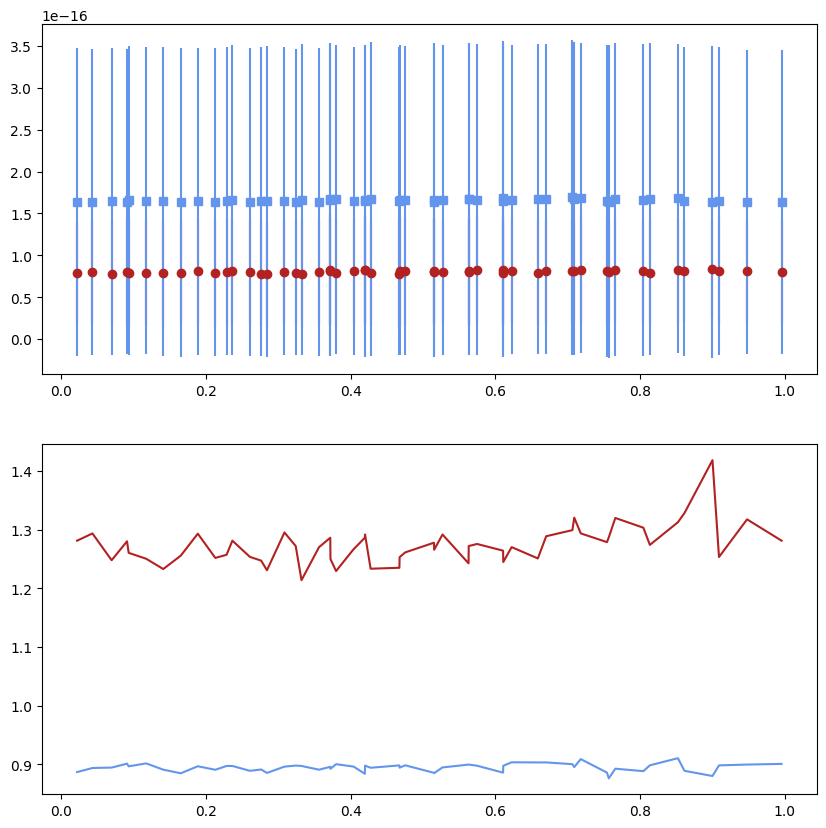

In [65]:
# plot in a single plot 2 subplots:
# top one needs to show both the light curves (at both wavelenghts)
# bottom one plot a SNR assuming that the flux error contains all your error sources 

fig,(ax1,ax2) = plt.subplots( 2,1 , figsize = (10, 10))
ax1.errorbar( lc_128[:,0], lc_128[:,1], yerr=lc_128[ :,2 ], 
             linestyle='none' , marker = 'o',  color= 'firebrick')
ax1.errorbar( lc_136[:,0], lc_136[:,1], yerr=lc_136[ :,2 ], 
             linestyle='none', marker = 's', color='cornflowerblue')

ax2.plot( lc_128[:,0], lc_128[:,1]/lc_128[ :,2 ], color= 'firebrick' )
ax2.plot( lc_136[:,0], lc_136[:,1]/lc_136[ :,2 ] , color='cornflowerblue')

### observations done with same instrument; SNR hugely different
### Is it something to do with how WFC3 responds to photons? Check SVO out: 
http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?mode=browse&gname=HST&gname2=WFC3_IR&asttype=

#### 1. (15 minutes) You measure a quantity $x$ and find that it is $1.30\pm0.15$. You also measure a quantity $y$ and find that it is $0.50\pm0.09$. You have a quantity z that can be one of the two functions of x and y:

- $$z = \sin xy $$ 
- $$z = y e^{-x^2} $$

#### For each function find the value of z and the value of $\sigma_z$ (z's own uncertainty) based on the measurements and uncertainties. Print an informative statement that lets us know what $z\pm\sigma_z$ is. Format output to 2 decimal digit accuracy.

### 2. (30 min)

### Get images from files astro_snr_test1 and astro_snr_test2. They are 'observations' of the same object made with your telescope at two different nights. 
- How many observations did you get for each night?
- Which night do you expect to have a better prospect for detection?
- Plot a few individual images. Do you think you have a detection?
- What can you do to improve your image?
- What is your observations of?

- Assuming that your noise is that of pixel 0,0, what is your SNR for your two observation nights?


In [66]:
import os
import pandas as pd

list1 = os.listdir(r"C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week5\astro_snr_test1")
list2 = os.listdir(r"C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week5\astro_snr_test2")

numb1 = len(list1)
numb2 = len(list2)

print(numb1, numb2)

# So we would expect that the second night has better detections because we have more data.

41 121


In [67]:
print(list1)

['image_0.txt', 'image_1.txt', 'image_10.txt', 'image_11.txt', 'image_12.txt', 'image_13.txt', 'image_14.txt', 'image_15.txt', 'image_16.txt', 'image_17.txt', 'image_18.txt', 'image_19.txt', 'image_2.txt', 'image_20.txt', 'image_21.txt', 'image_22.txt', 'image_23.txt', 'image_24.txt', 'image_25.txt', 'image_26.txt', 'image_27.txt', 'image_28.txt', 'image_29.txt', 'image_3.txt', 'image_30.txt', 'image_31.txt', 'image_32.txt', 'image_33.txt', 'image_34.txt', 'image_35.txt', 'image_36.txt', 'image_37.txt', 'image_38.txt', 'image_39.txt', 'image_4.txt', 'image_40.txt', 'image_5.txt', 'image_6.txt', 'image_7.txt', 'image_8.txt', 'image_9.txt']


In [68]:
images = []

for i in list1:
    filepath = r"C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week5\astro_snr_test1\\"
    data = pd.read_csv(filepath + i)
    images.append(data)

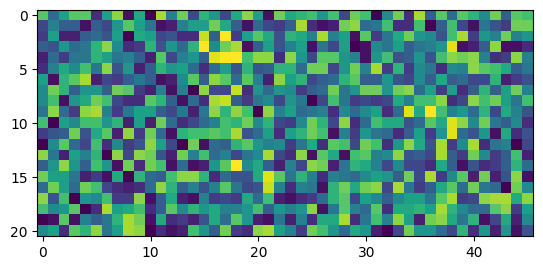

In [69]:
filepath = r"C:\Users\Alex\Desktop\AST5765\lectures_git\lectures_week5\astro_snr_test1\\"
rando = np.loadtxt(filepath + 'image_1.txt')
dm = plt.imshow(rando)

In [70]:
# 3D cube

d1, d2 = rando.shape
test1 = np.zeros( (d1, d2, numb1))

print(test1.shape)

(21, 46, 41)


In [71]:
for i in range(numb1):
    filename = "astro_snr_test1\image_{0:.0f}.txt".format(i)
    #print(filename)
    test1[:, :, i] = np.loadtxt(filename)

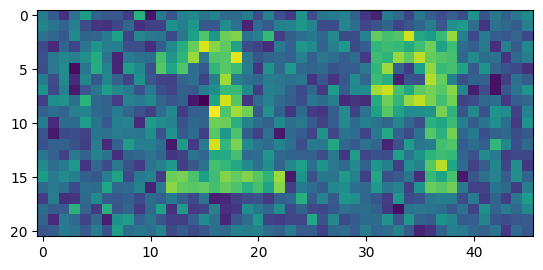

In [73]:
plt.imshow(np.sum( test1, axis = 2) )

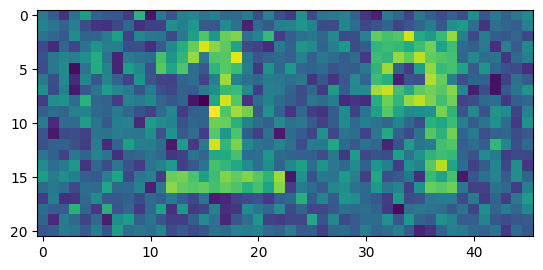

In [74]:
plt.imshow(np.mean( test1, axis = 2) )

### 3. (30 min) 

### The number of photons you receive from a source is 
$$ N = \frac{At}{E_\rm{phot}4\pi d^2}\int_{\Delta\lambda}F_{\rm obj}(\lambda) T(\lambda) {\rm d} \lambda$$

## where: 
   - $F_{\rm obj}$ is the flux measured at object
       - For a spherical blackbody (ok approximation for a star or planet), $F = 4\pi R^{2}\sigma T_{\mathrm{eff}}^{4}$
   - $\frac{A}{4\pi d^2}$ is fraction of that entering telescope (object is at distance d from us)
   - $T(\lambda)$ is optical transmission
    
1. Assume a star with a radius of 1$R_\odot$ and $T_\mathrm{eff} = 6000$K. How much is the flux it emits to space in a single wavelength (assume ${\rm d} \lambda =1$ and $E_\rm{phot}$ = 3.976e-19) ?

2. Assume the star is at a distance of 40pc away from us and we observe it with a telescope with of 10m diameter and $T(\lambda)$= 0.95. How many photons do we receive for integration times of 5sec, 10sec, 30sec, 1min, 5min and 10min? 

3. Repeat the above for a telescope diameter of 2m, 5m, 8.2m and 39m. 

4. Assuming a perfect world where your noise is only the photon noise, what is the SNR you get for each of the cases you calculated in Q2 and Q3? Plot your SNRs!
